In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
routes = pd.read_csv('../gtfs/2/google_transit/routes.txt')
stops = pd.read_csv('../gtfs/2/google_transit/stops.txt')
trips = pd.read_csv('../gtfs/2/google_transit/trips.txt')
stop_times = pd.read_csv('../gtfs/2/google_transit/stop_times.txt')

print("Routes:", len(routes))
print("Stops:", len(stops))
print("Trips:", len(trips))
print("Stop times:", len(stop_times))

Routes: 35
Stops: 3064
Trips: 36647
Stop times: 570236


/var/folders/qw/999v1mjj1jqf4vrtqy31cwv80000gn/T/ipykernel_58341/3330317420.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv('../gtfs/2/google_transit/stop_times.txt')


In [3]:
routes.head()

,route_id,agency_id,route_short_name,route_long_name,route_type,route_color,route_text_color
0,aus:vic:vic-02-ALM:,NaN,Alamein,Alamein - City,400,152C6B,FFFFFF
1,aus:vic:vic-02-ALM-R:,NaN,Replacement Bus,Alamein - City,400,FE5000,FFFFFF
2,aus:vic:vic-02-BEG:,NaN,Belgrave,Belgrave - City,400,152C6B,FFFFFF
3,aus:vic:vic-02-BEG-R:,NaN,Replacement Bus,Belgrave - City,400,FE5000,FFFFFF
4,aus:vic:vic-02-CBE:,NaN,Cranbourne,Cranbourne - City,400,34ACE1,000000


In [4]:
# 过滤掉replacement bus，只看正常线路
real_routes = routes[~routes['route_short_name'].str.contains('Replacement', na=False)]
print(real_routes[['route_short_name', 'route_long_name']])

         route_short_name               route_long_name
0                 Alamein                Alamein - City
2                Belgrave               Belgrave - City
4              Cranbourne             Cranbourne - City
6             City Circle                           NaN
7             Craigieburn            Craigieburn - City
9               Frankston              Frankston - City
11          Glen Waverley          Glen Waverley - City
13            Hurstbridge            Hurstbridge - City
15               Lilydale               Lilydale - City
17                 Mernda                 Mernda - City
19               Pakenham               Pakenham - City
21  Flemington Racecourse  Flemington Racecourse - City
23            Sandringham            Sandringham - City
25            Stony Point       Stony Point - Frankston
27                Sunbury                Sunbury - City
29                Upfield                Upfield - City
31               Werribee               Werribee

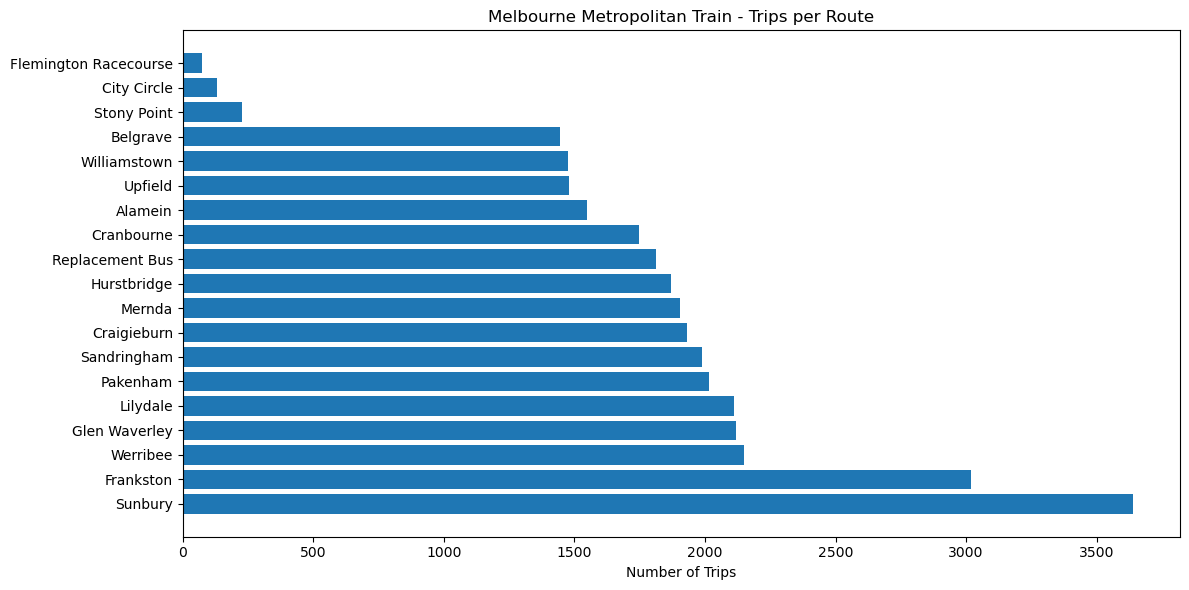

In [7]:
# 统计每条线路的trip数量
trips_per_route = trips.groupby('route_id').size().reset_index(name='trip_count')
trips_per_route = trips_per_route.merge(routes[['route_id', 'route_short_name']], on='route_id')
trips_per_route = trips_per_route.sort_values('trip_count', ascending=False)

# 画图
plt.figure(figsize=(12, 6))
plt.barh(trips_per_route['route_short_name'], trips_per_route['trip_count'])
plt.xlabel('Number of Trips')
plt.title('Melbourne Metropolitan Train - Trips per Route')
plt.tight_layout()
plt.savefig('../outputs/trips_per_route.png')
plt.show()